<a href="https://colab.research.google.com/github/ganesh10-code/DL_Lab/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7

18. Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, ResNet and note your observations. Also apply above models on your own dataset.


**Splitting data into test and validation**

In [ ]:
import os
import shutil
import random

SOURCE_DIR = "/kaggle/input/datasets/ganeshh10/vehicles-dataset/Vehicles"
OUTPUT_DIR = "vehicle_split_dataset"      # output folder
SPLIT_RATIO = 0.8           # 80% train, 20% validation

# Supported image formats
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")


# CREATE OUTPUT FOLDERS
train_dir = os.path.join(OUTPUT_DIR, "train")
val_dir = os.path.join(OUTPUT_DIR, "val")

for split in ["train", "val"]:
    for category in os.listdir(SOURCE_DIR):
        category_path = os.path.join(SOURCE_DIR, category)

        # skip non-folder files
        if not os.path.isdir(category_path):
            continue

        os.makedirs(os.path.join(OUTPUT_DIR, split, category), exist_ok=True)


# SPLITTING PROCESS
print("\n Starting dataset split...\n")

for category in os.listdir(SOURCE_DIR):
    category_path = os.path.join(SOURCE_DIR, category)

    if not os.path.isdir(category_path):
        continue

    # Filter valid images only
    images = [
        img for img in os.listdir(category_path)
        if img.endswith(VALID_EXTENSIONS)
    ]

    if len(images) == 0:
        print(f"No valid images found in {category}")
        continue

    # Shuffle images
    random.shuffle(images)

    # Split index
    split_index = int(len(images) * SPLIT_RATIO)

    train_images = images[:split_index]
    val_images = images[split_index:]

    print(f"{category}")
    print(f"   Total: {len(images)} | Train: {len(train_images)} | Val: {len(val_images)}")

    # Copy TRAIN images
    for img in train_images:
        src = os.path.join(category_path, img)
        dst = os.path.join(train_dir, category, img)

        try:
            shutil.copy2(src, dst)
        except Exception as e:
            print(f"Error copying {img}: {e}")

    # Copy VALIDATION images
    for img in val_images:
        src = os.path.join(category_path, img)
        dst = os.path.join(val_dir, category, img)

        try:
            shutil.copy2(src, dst)
        except Exception as e:
            print(f"Error copying {img}: {e}")

print("\n✅ Dataset split completed successfully!")


 Starting dataset split...

Auto_Rickshaws
   Total: 50 | Train: 40 | Val: 10
Ships
   Total: 49 | Train: 39 | Val: 10
Cars
   Total: 50 | Train: 40 | Val: 10
Motorcycles
   Total: 49 | Train: 39 | Val: 10
Bikes
   Total: 50 | Train: 40 | Val: 10
Trains
   Total: 49 | Train: 39 | Val: 10

✅ Dataset split completed successfully!


**Data Loading**
- Loading data
- Resizing into 244, 244
- transforming into numerical vectors

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_CLASSES = 6
BATCH_SIZE = 32
EPOCHS = 5

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("/kaggle/working/vehicle_split_dataset/train", transform=transform)
val_data = datasets.ImageFolder("/kaggle/working/vehicle_split_dataset/val", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)

**LeNet implementation**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self, num_classes=6):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

**Defining pre-trained models using torchvision**

In [ ]:
from torchvision import models

def get_model(model_name, num_classes):

    if model_name == "lenet":
        return LeNet(num_classes)

    elif model_name == "alexnet":
        model = models.alexnet(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == "resnet":
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(2048, num_classes)

    elif model_name == "googlenet":
        model = models.googlenet(pretrained=True)
        model.fc = nn.Linear(1024, num_classes)

    elif model_name == "zfnet":
          model = ZFNet(num_classes)

    return model

**Defining ZF-Net**

In [ ]:
class ZFNet(nn.Module):
    def __init__(self, num_classes=6):
        super(ZFNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((5, 5))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

**Model Training**

In [ ]:
import torch.optim as optim

def train_model(model, train_loader, val_loader, epochs=5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # VALIDATION
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Accuracy: {accuracy:.2f}%")

    return model, train_losses, val_accuracies

**Visualizing Training graph**

In [ ]:
import matplotlib.pyplot as plt

def plot_training_graphs(losses, accuracies, model_name):

    # Loss Graph
    plt.figure()
    plt.plot(losses)
    plt.title(f"{model_name} - Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

    # Accuracy Graph
    plt.figure()
    plt.plot(accuracies)
    plt.title(f"{model_name} - Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid()
    plt.show()

**Confusion Matrix function**

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def get_predictions(model, dataloader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def plot_confusion_matrix(y_true, y_pred, class_names, model_name):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


 Training LENET...
Epoch 1, Loss: 1.8152, Val Accuracy: 30.87%
Epoch 2, Loss: 1.6720, Val Accuracy: 39.60%
Epoch 3, Loss: 1.4624, Val Accuracy: 55.03%
Epoch 4, Loss: 1.2445, Val Accuracy: 51.68%
Epoch 5, Loss: 1.0425, Val Accuracy: 57.05%


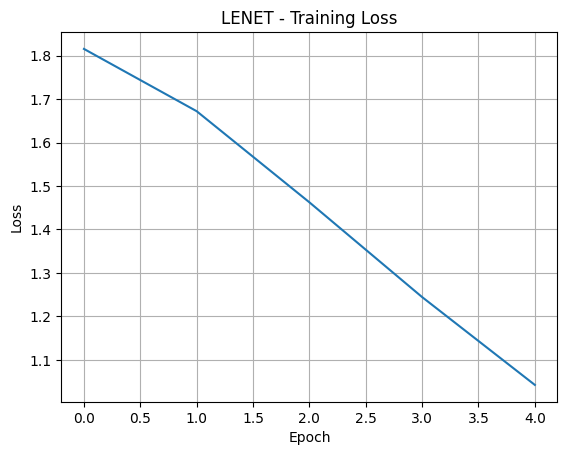

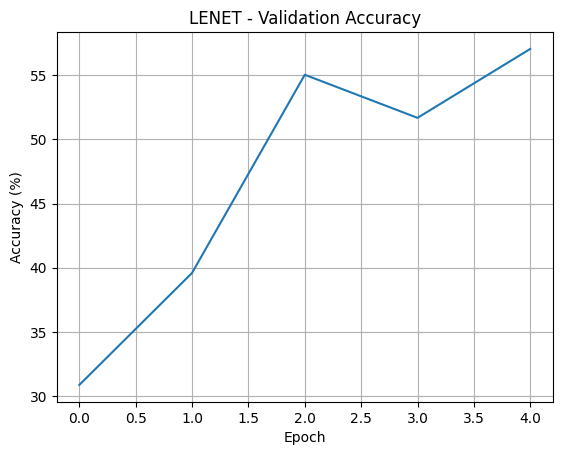

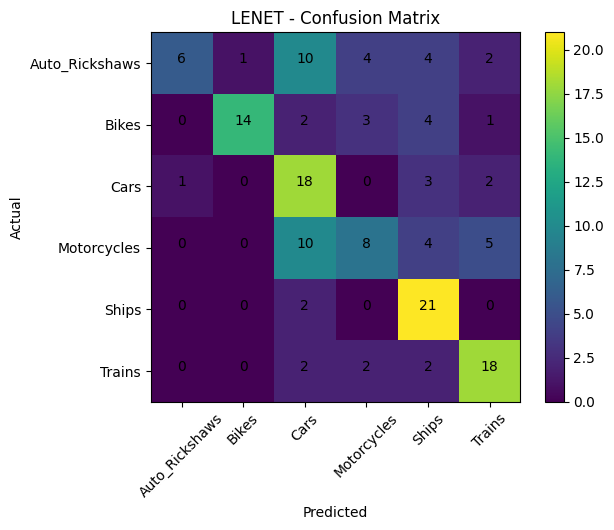


 Training ALEXNET...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 3.4078, Val Accuracy: 20.13%
Epoch 2, Loss: 1.7857, Val Accuracy: 24.16%
Epoch 3, Loss: 1.9168, Val Accuracy: 23.49%
Epoch 4, Loss: 1.7856, Val Accuracy: 18.79%
Epoch 5, Loss: 2.0071, Val Accuracy: 16.11%


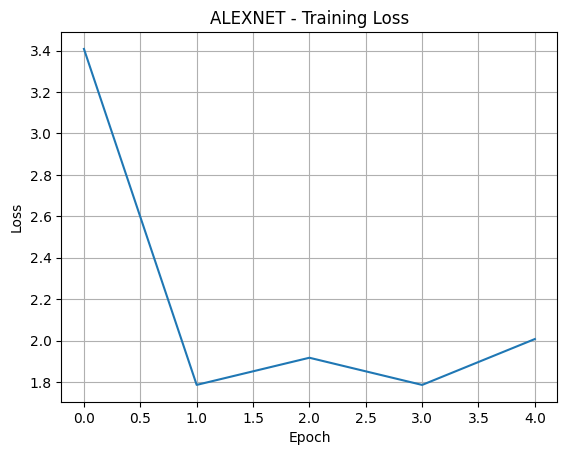

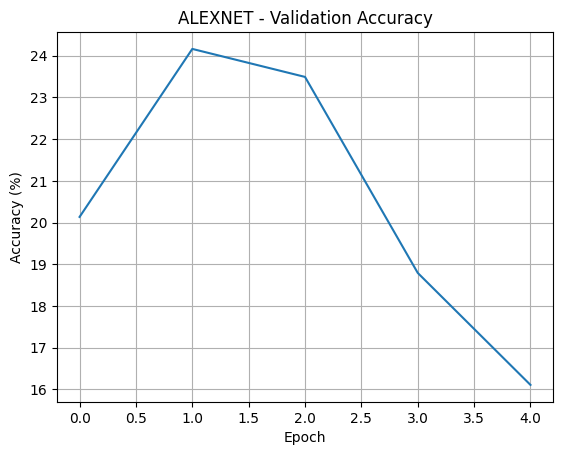

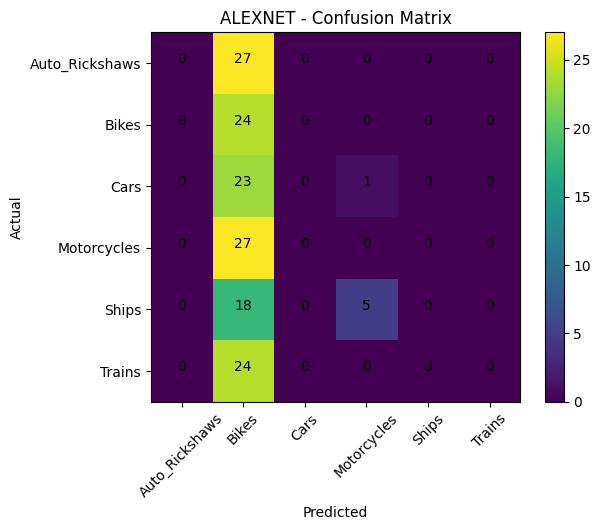


 Training ZFNET...
Epoch 1, Loss: 2.0881, Val Accuracy: 16.11%
Epoch 2, Loss: 1.7916, Val Accuracy: 15.44%
Epoch 3, Loss: 1.7897, Val Accuracy: 20.13%
Epoch 4, Loss: 1.7760, Val Accuracy: 16.78%
Epoch 5, Loss: 1.7511, Val Accuracy: 26.17%


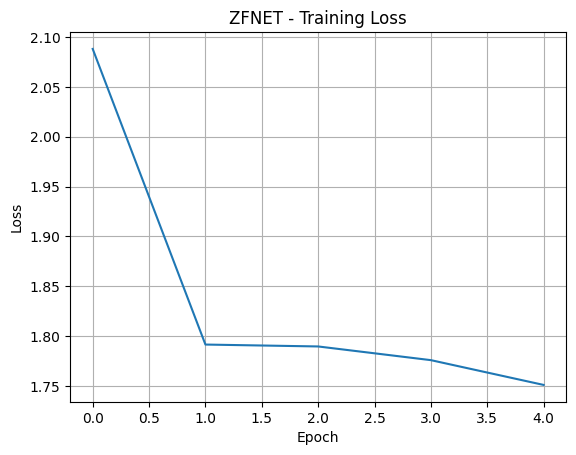

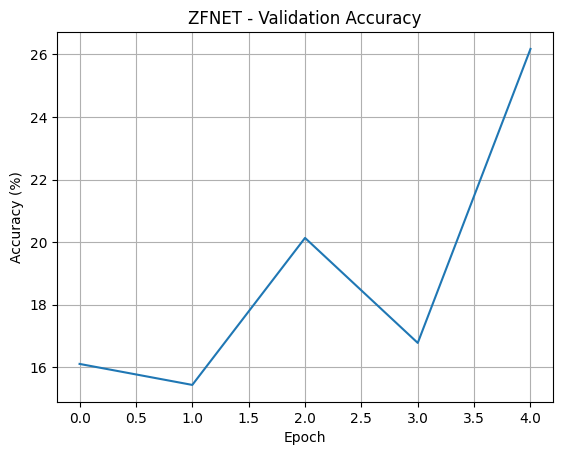

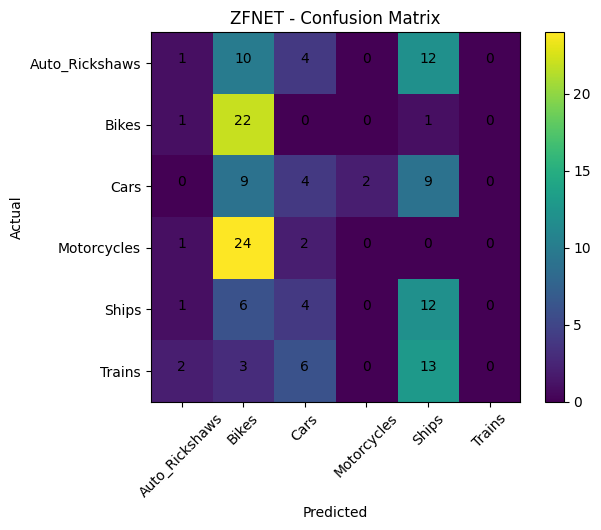


 Training VGG16...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 2.2963, Val Accuracy: 18.12%
Epoch 2, Loss: 1.8109, Val Accuracy: 15.44%
Epoch 3, Loss: 1.8232, Val Accuracy: 18.12%
Epoch 4, Loss: 1.8157, Val Accuracy: 16.11%
Epoch 5, Loss: 1.8048, Val Accuracy: 18.12%


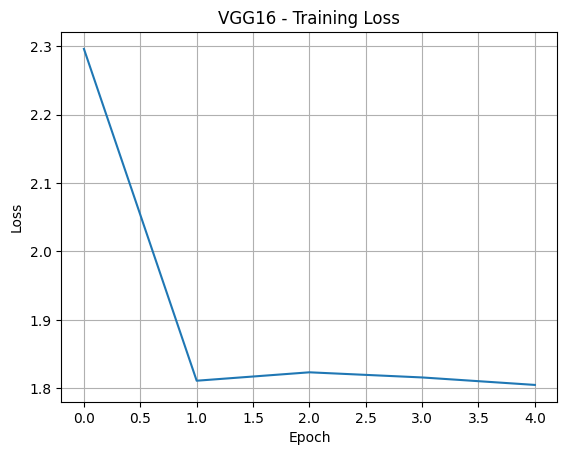

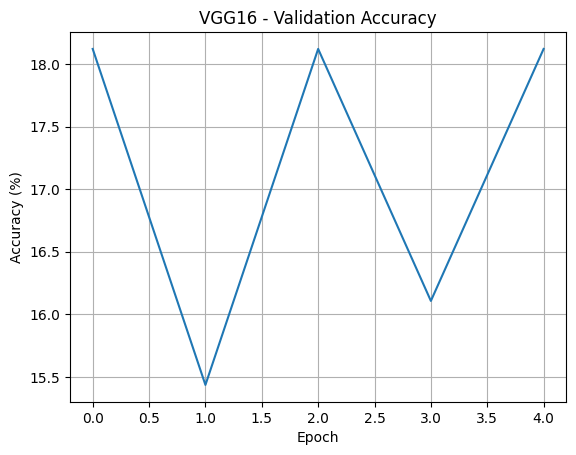

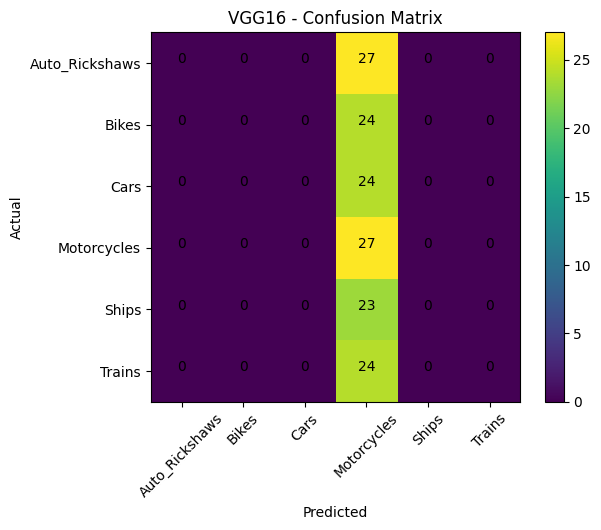


 Training GOOGLENET...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.7131, Val Accuracy: 90.60%
Epoch 2, Loss: 0.0750, Val Accuracy: 96.64%
Epoch 3, Loss: 0.2316, Val Accuracy: 94.63%
Epoch 4, Loss: 0.3063, Val Accuracy: 83.89%
Epoch 5, Loss: 0.2313, Val Accuracy: 95.30%


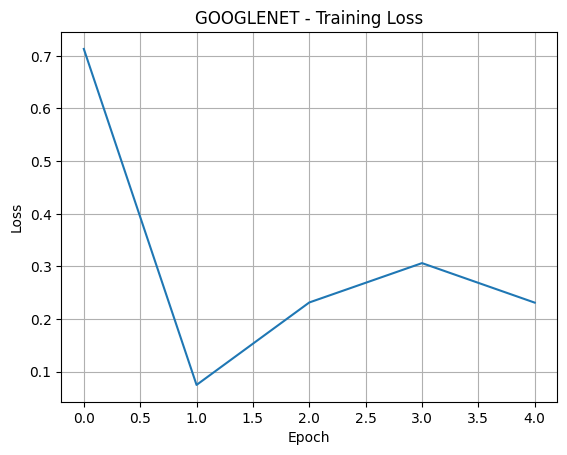

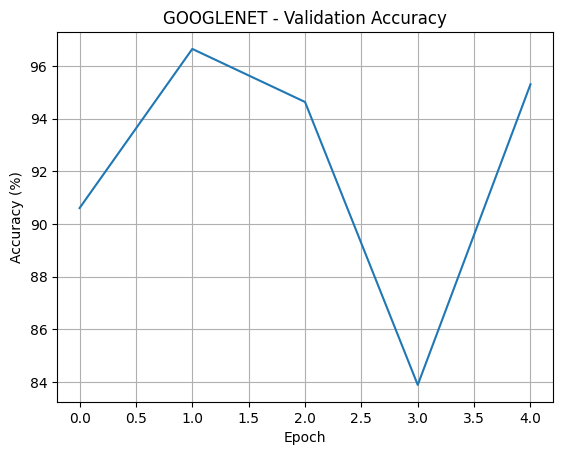

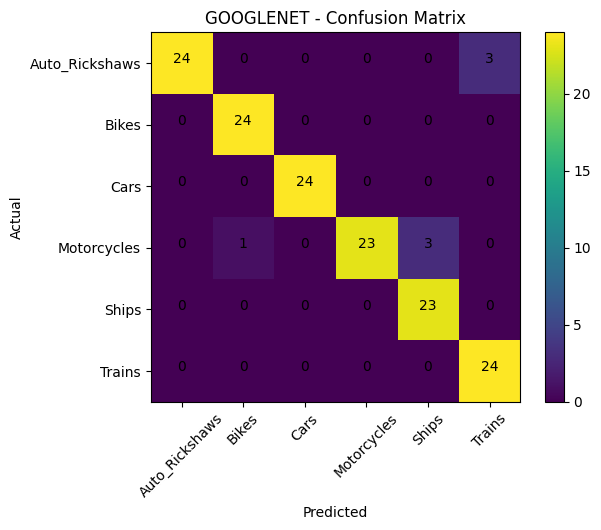


 Training RESNET...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.8853, Val Accuracy: 29.53%
Epoch 2, Loss: 0.7806, Val Accuracy: 16.78%
Epoch 3, Loss: 0.7003, Val Accuracy: 52.35%
Epoch 4, Loss: 0.4627, Val Accuracy: 93.96%
Epoch 5, Loss: 0.2600, Val Accuracy: 53.02%


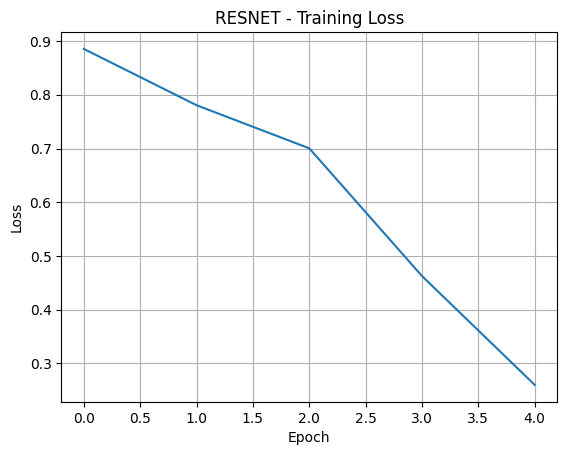

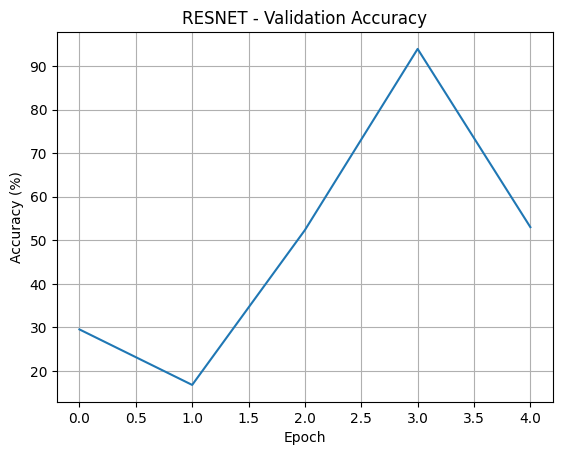

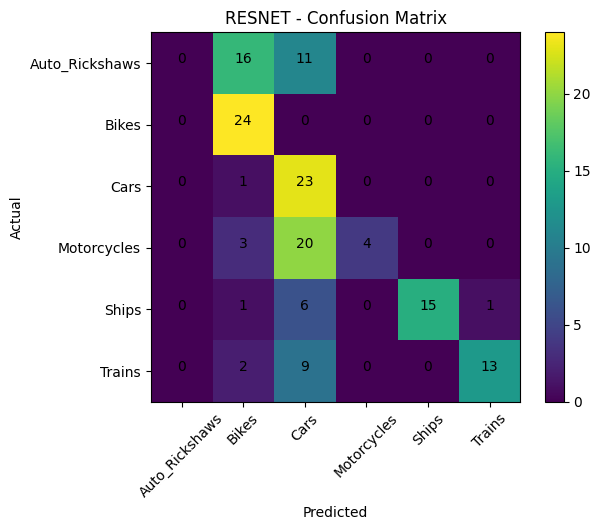

In [ ]:
models_list = ["lenet", "alexnet", "zfnet", "vgg16", "googlenet", "resnet"]

class_names = train_data.classes

for m in models_list:
    print(f"\n Training {m.upper()}...")

    model = get_model(m, NUM_CLASSES)

    model, losses, accuracies = train_model(model, train_loader, val_loader, EPOCHS)

    # Plot graphs
    plot_training_graphs(losses, accuracies, m.upper())

    # Confusion matrix
    y_true, y_pred = get_predictions(model, val_loader)
    plot_confusion_matrix(y_true, y_pred, class_names, m.upper())

# Final Accuracy Comparison
Model	     Best Val Accuracy
- LeNet	     ~57%
- AlexNet	 ~24%
- ZFNet	     ~26%
- VGG16	     ~18%
- GoogLeNet	 ~96%
- ResNet50	 ~94% (unstable)

# FINAL OBSERVATIONS
**1. GoogLeNet consistently performed the BEST**

*Accuracy: ~90% – 96%*

- Uses Inception modules
- Extracts multi-scale features (1×1, 3×3, 5×5)
- Efficient even with smaller datasets

👉 **Conclusion:**

GoogLeNet shows consistently high performance across runs, making it the most reliable model in this experiment.

**2. ResNet showed HIGH but UNSTABLE performance**

*Accuracy range: ~16% → 94%*

- Uses skip connections
- Can learn deep representations
**Problem:**
- Accuracy fluctuates heavily
- Indicates training instability and Sensitivity to data split

👉 **Conclusion:**

ResNet has high potential but requires proper tuning and more epochs for stable performance.


**3. LeNet performed surprisingly stable**

*Accuracy: ~50% – 57%*

- Simple architecture
- Less prone to overfitting

👉 **Conclusion:**

LeNet performs consistently and is suitable for small datasets, though less powerful than modern architectures.

**4. AlexNet, ZFNet, VGG16 performed POORLY**
Observations:
- Accuracy between 15% – 30%
- Very unstable
  
**Why did they fail?**
1. Overfitting / Underfitting:
   - Large models + small dataset
2. Insufficient training (only 5 epochs):
   - Deep models need more time to converge
3. Transfer learning not optimized:
   - No layer freezing or fine-tuning strategy used
4. VGG16 is very heavy:
   - ~138M parameters → needs more data


# Important Patterns Observed

Due to random dataset splitting:
- Results vary across runs
- Some models (like ResNet) show high variance
- Some models (like LeNet, GoogLeNet) remain stable

*Bigger model ≠ Better performance ❌*

Instead:

*Stable Model > Occasionally High Accuracy Model*

*Right model + Right data + Proper training = Best performance*

# Key Learning from Experiment
1. Architecture matters
    *GoogLeNet > ResNet > LeNet > others pre-trained models* (in this testcase)
2. Stability matters
    - GoogLeNet is both accurate and stable
    - ResNet is powerful but unstable
3. Dataset size is critical
    - Small dataset → simple models work better
4. Transfer learning must be handled carefully
    - Just loading pretrained weights is NOT enough
5. Epochs are too small for deep networks

# FINAL CONCLUSION

Among all evaluated CNN models, GoogLeNet consistently achieved the highest validation accuracy (~90–96%) due to its efficient Inception architecture and ability to capture multi-scale features.

ResNet demonstrated high potential with peak accuracy reaching ~94%, but showed significant instability across epochs due to sensitivity to data splits and insufficient training.

LeNet provided stable and consistent performance (~50–57%) and proved effective for smaller datasets.

In contrast, deeper models such as VGG16, AlexNet, and ZFNet underperformed due to limited data, insufficient training epochs, and lack of proper transfer learning strategies.

This experiment highlights that both model architecture and training methodology significantly influence performance, and that stability is as important as peak accuracy.